In [3]:
import pandas as pd
import kagglehub

# 1. Dataset download karna
path = kagglehub.dataset_download("shivamb/netflix-shows")
print("Dataset yahan rakha hai:", path)

# 2. Pandas (helper) ko us path se CSV file padhne ke liye bolna
df = pd.read_csv(f"{path}/netflix_titles.csv")

# 3. Table par shuru ki 5 rows (data) dekhna
df.head()

c:\Users\himes_9gylj1r\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.34M/1.34M [00:04<00:00, 291kB/s]

Extracting files...


Dataset yahan rakha hai: C:\Users\himes_9gylj1r\.cache\kagglehub\datasets\shivamb\netflix-shows\versions\5


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Step 2: Data Cleaning (Kachra saaf karna)

# 1. Jo columns humare liye zaroori hain, agar unme kuch gayab hai toh us poori row ko hata denge
df_clean = df.dropna(subset=['rating', 'duration', 'date_added'])

# 2. 'director' aur 'country' mein agar data nahi hai, toh wahan 'Unknown' (Pata nahi) likh denge
df_clean.loc[:, 'country'] = df_clean['country'].fillna('Unknown')
df_clean.loc[:, 'director'] = df_clean['director'].fillna('Unknown')

# 3. Check karte hain ki saaf hone ke baad ab kitna data bacha hai
print("Data safaai ka kaam poora hua!")
print("Bachi hui rows aur columns:", df_clean.shape)

Data safaai ka kaam poora hua!
Bachi hui rows aur columns: (8790, 12)


C:\Users\himes_9gylj1r\AppData\Local\Temp\ipykernel_22116\275258860.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df_clean, palette='Set2')


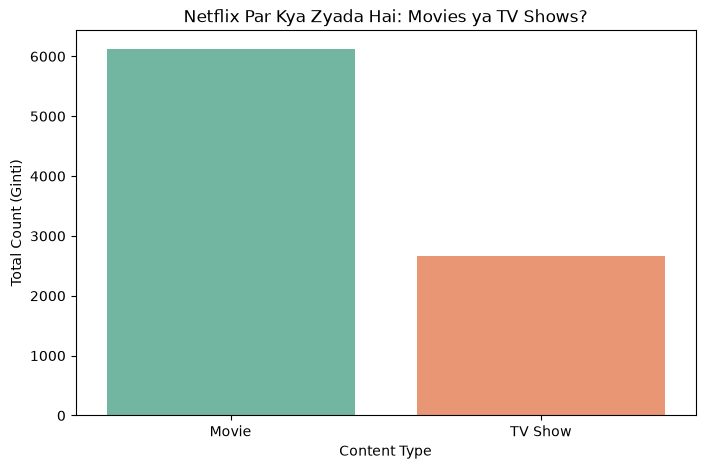

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Movies vs TV Shows ka chart banana

# 1. Drawing sheet ka size tay karte hain ki chart kitna bada hoga
plt.figure(figsize=(8,5))

# 2. Seaborn (humara color brush) se bolte hain ki 'type' wale column ka chart bana de
sns.countplot(x='type', data=df_clean, palette='Set2')

# 3. Chart ko ek title (naam) dete hain taaki dekhne wale ko samajh aaye
plt.title('Netflix Par Kya Zyada Hai: Movies ya TV Shows?')
plt.xlabel('Content Type')
plt.ylabel('Total Count (Ginti)')

# 4. Drawing poori hui, ab chart sabko dikha do!
plt.show()